In [1]:
import pandas as pd

data = pd.read_csv("fake_news_dataset.csv")

print(data.head())

                                  title  \
0               Foreign Democrat final.   
1   To offer down resource great point.   
2          Himself church myself carry.   
3                  You unit its should.   
4  Billion believe employee summer how.   

                                                text        date    source  \
0  more tax development both store agreement lawy...  2023-03-10  NY Times   
1  probably guess western behind likely next inve...  2022-05-25  Fox News   
2  them identify forward present success risk sev...  2022-09-01       CNN   
3  phone which item yard Republican safe where po...  2023-02-07   Reuters   
4  wonder myself fact difficult course forget exa...  2023-04-03       CNN   

                 author    category label  
0          Paula George    Politics  real  
1           Joseph Hill    Politics  fake  
2        Julia Robinson    Business  fake  
3  Mr. David Foster DDS     Science  fake  
4         Austin Walker  Technology  fake  


In [2]:
# Fake News Detection using Naive Bayes

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("fake_news_dataset.csv")

# Show first rows
print("Dataset Preview:\n")
print(data.head())

# Remove missing values
data = data.dropna()

# Combine title and text
data["content"] = data["title"] + " " + data["text"]

# Convert labels (real/fake → numbers)
encoder = LabelEncoder()
data["label"] = encoder.fit_transform(data["label"])

# Features and labels
X = data["content"]
y = data["label"]

# Convert text into numerical vectors
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)
X_vector = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_vector, y, test_size=0.2, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Dataset Preview:

                                  title  \
0               Foreign Democrat final.   
1   To offer down resource great point.   
2          Himself church myself carry.   
3                  You unit its should.   
4  Billion believe employee summer how.   

                                                text        date    source  \
0  more tax development both store agreement lawy...  2023-03-10  NY Times   
1  probably guess western behind likely next inve...  2022-05-25  Fox News   
2  them identify forward present success risk sev...  2022-09-01       CNN   
3  phone which item yard Republican safe where po...  2023-02-07   Reuters   
4  wonder myself fact difficult course forget exa...  2023-04-03       CNN   

                 author    category label  
0          Paula George    Politics  real  
1           Joseph Hill    Politics  fake  
2        Julia Robinson    Business  fake  
3  Mr. David Foster DDS     Science  fake  
4         Austin Walker  Technolog

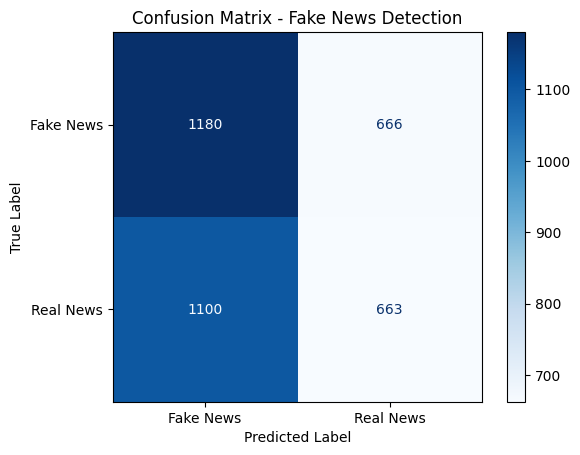

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# predictions on test data
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fake News", "Real News"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Fake News Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [5]:
print(encoder.classes_)

['fake' 'real']


In [6]:
print(data["label"].value_counts())

label
0    9095
1    8950
Name: count, dtype: int64


In [12]:
while True:
    user_news = input("Enter a news headline (type 'stop' to exit): ")

    if user_news.lower() == "stop":
        break

    news_vector = vectorizer.transform([user_news])
    prediction = model.predict(news_vector)[0]

    if prediction == 0:
        print("Result: FAKE NEWS\n")
    else:
        print("Result: REAL NEWS\n")

Enter a news headline (type 'stop' to exit): stop
